In [19]:
# Si falta alguna libreria en el entorno, descomenta y ejecuta esta celda:
# %pip install pandas numpy matplotlib seaborn scikit-learn

# Path nos permite construir rutas de archivos de forma compatible con Windows/Mac/Linux.
from pathlib import Path

# numpy se usa para operaciones numericas y metricas como RMSE.
import numpy as np

# pandas se usa para cargar CSVs y trabajar con tablas.
import pandas as pd

# matplotlib y seaborn se usan para graficos.
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split divide datos en entrenamiento y test.
from sklearn.model_selection import train_test_split

# Modelos basicos de regresion y clasificacion.
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Metricas para evaluar regresion, clasificacion y forecasting.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)

# Pipeline empaqueta pasos repetibles; StandardScaler escala variables numericas.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Estilo visual de los graficos y configuracion de pandas.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Ruta de datos. Funciona tanto si abres el notebook desde su carpeta
# como si lo ejecutas desde la raiz del workspace.
DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("modulo 2") / "intro ciencia de datos" / "data"


Pregunta --> datos --> preparación --> X/Y --> modelo --> metricas --> decisiones

In [20]:
df_modelo = pd.read_csv(DATA_DIR / "clientes_modelado.csv")

df_modelo.head()

,edad,ingresos_mensuales,visitas_web_30d,compras_previas,dias_desde_ultima_compra,es_premium,descuento_recibido,gasto_proximo_mes,compra_proximo_mes
0,22,2703.0,5,1,77,0,6.4,197.49,0
1,58,2189.0,5,5,119,0,20.4,244.66,0
2,52,744.0,5,2,83,1,12.2,220.37,0
3,40,3089.0,4,3,133,0,11.9,306.84,0
4,40,1786.0,3,7,154,0,29.2,259.58,1


In [21]:
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   edad                      900 non-null    int64  
 1   ingresos_mensuales        900 non-null    float64
 2   visitas_web_30d           900 non-null    int64  
 3   compras_previas           900 non-null    int64  
 4   dias_desde_ultima_compra  900 non-null    int64  
 5   es_premium                900 non-null    int64  
 6   descuento_recibido        900 non-null    float64
 7   gasto_proximo_mes         900 non-null    float64
 8   compra_proximo_mes        900 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 63.4 KB


In [22]:
df_modelo.columns

Index(['edad', 'ingresos_mensuales', 'visitas_web_30d', 'compras_previas',
       'dias_desde_ultima_compra', 'es_premium', 'descuento_recibido',
       'gasto_proximo_mes', 'compra_proximo_mes'],
      dtype='str')

In [23]:
target_regresion = "gasto_proximo_mes"

features_clientes = [
    "edad", 
    "ingresos_mensuales",
    "visitas_web_30d",
    "compras_previas",
    "dias_desde_ultima_compra",
    "es_premium",
    "descuento_recibido",
    ]

print("Target de regresion:", target_regresion)
print("Features de clientes:", features_clientes)


Target de regresion: gasto_proximo_mes
Features de clientes: ['edad', 'ingresos_mensuales', 'visitas_web_30d', 'compras_previas', 'dias_desde_ultima_compra', 'es_premium', 'descuento_recibido']


No añadimos "gasto_proximo_mes" porque es la variable objetivo. En un caso real también se evita columnas generadas después del evento que queremos predecir (leakage).

In [24]:
# X contiene la variables de entrada
x = df_modelo[features_clientes]

#y contiene las variables objetivo
y = df_modelo["gasto_proximo_mes"]

# confirmamos que aqui ya no está la variable objetivo
x.head()

,edad,ingresos_mensuales,visitas_web_30d,compras_previas,dias_desde_ultima_compra,es_premium,descuento_recibido
0,22,2703.0,5,1,77,0,6.4
1,58,2189.0,5,5,119,0,20.4
2,52,744.0,5,2,83,1,12.2
3,40,3089.0,4,3,133,0,11.9
4,40,1786.0,3,7,154,0,29.2


In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    x, #variables de entrada
    y, #variable objetivo
    test_size=0.2, # 20% de los datos para test, 80% para entrenamiento
    random_state=42 #semilla fija para reproducibilidad
)

#comprobar filas y columnas de cada conjunto
print("Train:", x_train.shape)  
print("Test:", x_test.shape)


Train: (720, 7)
Test: (180, 7)


In [26]:
#creadno el modelo de regresion --> linerRegression
modelo_regresion = LinearRegression()

#entrenamos el modelo con los datos de entrenamiento
modelo_regresion.fit(x_train, y_train)

#predict aplica el modelo entrenado a clientes nuevos (x_test) para predecir su gasto
pred_regresion = modelo_regresion.predict(x_test)

# mostramos las 10 primeras predicciones
pred_regresion[:10]


array([214.42283329, 274.68375581, 245.25167679, 142.87121018,
       286.26842314, 238.89361446, 265.70369905, 206.88694634,
       244.95672655, 186.63260255])

In [27]:
#MAE: error absoluto medio
mae = mean_absolute_error(y_test, pred_regresion)
print("MAE:", mae)

#RMSE: raiz del error cuadratico medio
rmse = np.sqrt(mean_squared_error(y_test, pred_regresion))
print("RMSE:", rmse)

# R2: proporción de varianza explicada por el modelo
r2 = r2_score(y_test, pred_regresion)
print("R2:", r2)


MAE: 30.530999757993555
RMSE: 37.22635080720656
R2: 0.7481579312536297


In [28]:
# creamos una tabla comparativa entre valores reales y predichos

resultados_regresion = pd.DataFrame(
    {
    "real": y_test,
    "predicho": pred_regresion,
    "error_absoluto": abs(y_test - pred_regresion)
    }
).round(2)

# mostramos solo 10 filas
resultados_regresion.head(10)

,real,predicho,error_absoluto
70,188.16,214.42,26.26
827,287.39,274.68,12.71
231,280.57,245.25,35.32
588,80.18,142.87,62.69
39,288.94,286.27,2.67
731,230.54,238.89,8.35
299,294.07,265.70,28.37
110,228.05,206.89,21.16
72,315.81,244.96,70.85
86,142.54,186.63,44.09


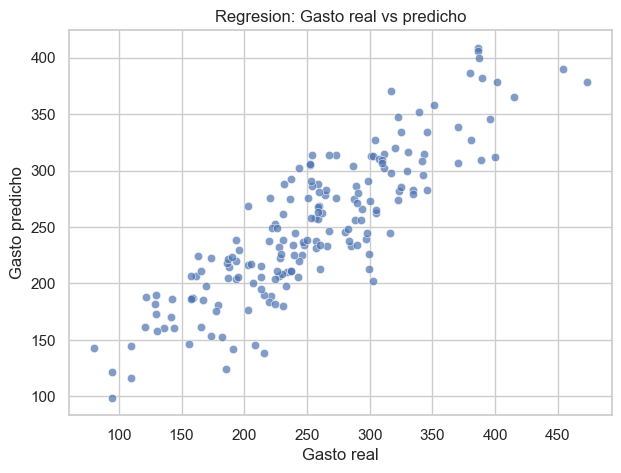

In [29]:
# grafica de dispersion entre valores reales y predichos
plt.figure(figsize=(7,5))

# eje x gasto real, eje y gasto predicho
sns.scatterplot(x=y_test, y=pred_regresion, alpha=0.7)

plt.xlabel("Gasto real")
plt.ylabel("Gasto predicho")
plt.title("Regresion: Gasto real vs predicho")
plt.show()

In [30]:
# en un regresion lineal, cada feature tiene un coeficiente que indica su impacto en la prediccion.
# el coeficiente positivo indica que a mayor valor de esa feature, mayor gasto predicho, y viceversa para coeficientes negativos.
# No es causalidad, solo una asociación que el modelo ha aprendido a partir de los datos.

coeficientes = pd.DataFrame(
    {
        "feature": features_clientes,
        "coeficiente": modelo_regresion.coef_
    }
).sort_values(by="coeficiente", ascending=False)

coeficientes


,feature,coeficiente
5,es_premium,72.334410
3,compras_previas,19.811741
2,visitas_web_30d,7.234480
6,descuento_recibido,1.225800
1,ingresos_mensuales,0.041787
0,edad,-0.043616
4,dias_desde_ultima_compra,-0.216591


EL coeficiente dice causalidad?

NO!  En este modelo lineal dice asociación dentro del modelo, manteniendo el resto ed variables constantes.

Regresion con menos variables.

Utilizad:
 -"visitas_web_30d"
 -"compras_previas"
 -"es_premium"

Pierde mucho rendimiento el modelo si usamos menos informacion??

In [31]:
features_reto_regresion = [
    "visitas_web_30d",
    "compras_previas",
    "es_premium",
]

# X_reto contiene solo esas tres variables.
X_reto = df_modelo[features_reto_regresion]

# La y es la misma que antes: queremos predecir el gasto del proximo mes.
y_reto = df_modelo["gasto_proximo_mes"]

# Repetimos la misma separacion train/test para comparar de forma justa.
X_train_reto, X_test_reto, y_train_reto, y_test_reto = train_test_split(
    X_reto,
    y_reto,
    test_size=0.2,
    random_state=42,
)

# Entrenamos otro modelo lineal, pero ahora con menos columnas.
modelo_reto_regresion = LinearRegression()
modelo_reto_regresion.fit(X_train_reto, y_train_reto)

# Predecimos sobre test y calculamos MAE.
pred_reto_regresion = modelo_reto_regresion.predict(X_test_reto)
mae_reto_regresion = mean_absolute_error(y_test_reto, pred_reto_regresion)

print(f"MAE modelo completo: {mae:.2f}")
print(f"MAE modelo con 3 variables: {mae_reto_regresion:.2f}")

MAE modelo completo: 30.53
MAE modelo con 3 variables: 43.20


CLasificación

In [32]:
df_modelo.head(10)

,edad,ingresos_mensuales,visitas_web_30d,compras_previas,dias_desde_ultima_compra,es_premium,descuento_recibido,gasto_proximo_mes,compra_proximo_mes
0,22,2703.0,5,1,77,0,6.4,197.49,0
1,58,2189.0,5,5,119,0,20.4,244.66,0
2,52,744.0,5,2,83,1,12.2,220.37,0
3,40,3089.0,4,3,133,0,11.9,306.84,0
4,40,1786.0,3,7,154,0,29.2,259.58,1
5,62,1846.0,4,3,76,0,14.8,224.67,0
6,22,1391.0,5,2,49,0,18.5,187.15,0
7,54,1744.0,13,0,104,0,19.7,208.20,0
8,28,2664.0,4,5,156,0,19.7,259.88,0
9,22,2139.0,5,3,177,0,7.5,156.15,0


In [35]:
x = df_modelo[features_clientes]
y = df_modelo["compra_proximo_mes"]

y.value_counts(normalize=True).rename({0: "No compra", 1: "Compra"})

compra_proximo_mes
No compra    0.812222
Compra       0.187778
Name: proportion, dtype: float64

In [37]:
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, #20% de los datos para test, 80% para entrenamiento
    random_state=42, # semilla fija para reproducibilidad
    stratify=y # estratificamos para mantener la misma proporción de clases en train y test
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(compra_proximo_mes
 0    0.8125
 1    0.1875
 Name: proportion, dtype: float64,
 compra_proximo_mes
 0    0.811111
 1    0.188889
 Name: proportion, dtype: float64)

In [38]:
# LogisticRegression es un modelo clasico de clasificacion
# Aunque ponga regresion no es para regresion, es para clasificacion binaria.
modelo_clasificacion = LogisticRegression(max_iter=1000)


modelo_clasificacion.fit(x_train, y_train)

prod_clasificacion = modelo_clasificacion.predict(x_test)

prod_clasificacion[:10]


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [ ]:

# Procentaje total de aciertos del modelo,
# es decir, la proporción de clientes que el modelo clasificó correctamente como compradores o no compradores.
accuracy = accuracy_score(y_test, prod_clasificacion)
print("Accuracy:", accuracy)
# Precision: de todos los clientes que el modelo predijo como compradores (compra_proximo_mes=1),
# qué proporción realmente compró.
precision = precision_score(y_test, prod_clasificacion)
print("Precision:", precision)
# Recall: de todos los clientes que realmente compraron, qué proporción el modelo identificó correctamente como compradores.
recall = recall_score(y_test, prod_clasificacion)
print("Recall:", recall)
# F1 Score: la media armónica entre precision y recall, que penaliza modelos que tengan un desequilibrio entre ambos.
f1 = f1_score(y_test, prod_clasificacion)
print("F1 Score:", f1)  


# Alta precision y alto recall: el modelo maneja perfectamente esa clase
# Alta precision y bajo recall: el modelo no detecta la clase muy bien, pero cuando lo hace es altamente confiable.
# Baja precisión y alto recall: La clase detecta bien la clase pero también incluye muestras de otras clases.
# Baja precisión y bajo recall: El modelo no logra clasificar la clase correctamente.



Accuracy: 0.8111111111111111
Precision: 0.5
Recall: 0.17647058823529413
F1 Score: 0.2608695652173913


Entrenar otro clasificador.

Antes usamos --> LogisticRegression
Ahora ---------> RandomForestClassifier

Preguntas?

- Mejora el accuracy?
- Mejora el recall de la clase compra?
- que modelo elegir si el objetivo es detectas más posibles compradores?


In [40]:
# Usamos la misma X e y que en la clasificacion anterior.
X = df_modelo[features_clientes]
y = df_modelo["compra_proximo_mes"]

# Repetimos la misma particion para comparar modelos de forma justa.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# RandomForestClassifier combina muchos arboles de decision.
# n_estimators indica cuantos arboles se entrenan.
# min_samples_leaf evita hojas demasiado pequeñas y reduce sobreajuste.
modelo_rf_clasificacion = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=3,
)

# Entrenamos el bosque aleatorio.
modelo_rf_clasificacion.fit(X_train, y_train)

# Predecimos clases para el conjunto de test.
pred_rf_clasificacion = modelo_rf_clasificacion.predict(X_test)

# Comparamos metricas principales.
print("RandomForestClassifier")
print(f"Accuracy:  {accuracy_score(y_test, pred_rf_clasificacion):.3f}")
print(f"Precision: {precision_score(y_test, pred_rf_clasificacion):.3f}")
print(f"Recall:    {recall_score(y_test, pred_rf_clasificacion):.3f}")
print(f"F1:        {f1_score(y_test, pred_rf_clasificacion):.3f}")


RandomForestClassifier
Accuracy:  0.817
Precision: 0.556
Recall:    0.147
F1:        0.233


Forecasting - Predecir el futuro.

In [41]:
df_ventas = pd.read_csv(DATA_DIR / "ventas_diarias_modelado.csv", parse_dates=["fecha"])

df_ventas.tail()

,fecha,ventas,dia,dia_semana,es_fin_de_semana,promo
175,2025-06-25,201.0,175,2,0,0
176,2025-06-26,195.0,176,3,0,0
177,2025-06-27,201.0,177,4,0,0
178,2025-06-28,168.0,178,5,1,0
179,2025-06-29,161.0,179,6,1,0


In [42]:
train = df_ventas.iloc[:-14].copy()  # Usamos todo excepto los últimos 14 días para entrenar
test = df_ventas.iloc[-14:].copy()   # Usamos los últimos 14 días para test


# Mostramos los rangos de fecha para reforzar la idea pasado -> futuro.
print("Train:", train["fecha"].min().date(), "a", train["fecha"].max().date())
print("Test: ", test["fecha"].min().date(), "a", test["fecha"].max().date())

Train: 2025-01-01 a 2025-06-15
Test:  2025-06-16 a 2025-06-29


In [43]:
# baseline: regla sencilla antes de entrenar un modelo complejo, siempre es bueno tener una referencia simple para comparar.
# shift(7) trae la venta de hace 7 dias para cada fecha
test["pred_baseline_7d"] = df_ventas["ventas"].shift(7).loc[test.index]

mae_baseline = mean_absolute_error(test["ventas"], test["pred_baseline_7d"])
print("MAE baseline 7 dias:", mae_baseline)


MAE baseline 7 dias: 22.357142857142858


In [44]:
features_forecasting = ["dia", "dia_semana", "es_fin_de_semana","promo"]

target_forecasting = "ventas"

modelo_forecasting = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=3,
)

modelo_forecasting.fit(train[features_forecasting], train[target_forecasting])

pred_forecasting = modelo_forecasting.predict(test[features_forecasting])

mae_forecasting = mean_absolute_error(test["ventas"], pred_forecasting)
print("MAE modelo forecasting:", mae_forecasting)


MAE modelo forecasting: 8.659420276152415


 - Quitar una variable del forecast y entrenar el mismo modelo. Quitad "promo"


 Pregunta:

        > Empeora el MAE si el modelo no sabe que dias hubo promocion?

       